# Milestone 3

Import all needed libraries and read the data set that has been cleaned as a result of milestone 1. 

In [ ]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from IPython.display import display

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
df_bike_clean = pd.read_csv("bike_data_clean.csv")
df_bike_clean.head()

# Add new feature: `weekdays`

Sort the starting time by weekdays. In one hot encoding, one category is left out in order to avoid  multicollinearity. (in this case: `Sunday`)


First, the `START TIME` needs to be converted to datetime value in order to be usable for the following task. We keep the original cleaned data set by making a copy of it to continue with the steps.

In [ ]:
# sort into weekdays
# one hot coded columns method

# first convert START TIME to datetime value
df_bike_clean['START TIME'] = pd.to_datetime(df_bike_clean['START TIME'])
df_bike_cleaned = df_bike_clean.copy()

# extract day the of the week
df_bike_cleaned['DAY OF WEEK'] = df_bike_cleaned["START TIME"].dt.day_name()

#ChatGPT: i want to improve the hot one coding because it does not start with monday, the column starts with wednesday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_bike_cleaned['DAY OF WEEK'] = pd.Categorical(df_bike_cleaned['DAY OF WEEK'], categories=day_order, ordered=True)
# until here ------------------

days_of_week = pd.get_dummies(df_bike_cleaned['DAY OF WEEK'])

# add column to database
df_bike_cleaned = pd.concat([df_bike_cleaned, days_of_week], axis=1)

df_bike_cleaned.head()

# Add new feature: `hour`

In [ ]:
#hour of day 
df_bike_cleaned['START TIME'] = pd.to_datetime(df_bike_cleaned['START TIME'])
df_bike_cleaned['HOUR OF DAY'] = df_bike_cleaned['START TIME'].dt.hour
df_bike_cleaned.tail()

# Visualization:
Number of bike trips starting and concurrent bike usage for every `hour` of day

In [ ]:
# Visualization 1
# bar chart how many trips startet in each hour
plt.figure(figsize=(9,6))
sns.countplot(x='HOUR OF DAY', data=df_bike_cleaned, color= "orange")

plt.title("Starting time for every hour")
plt.xlabel("Hour of day from 0h to 23h")
plt.ylabel("Number of bike trips starting")
plt.grid(axis= 'y')
plt.show()

# Visualization 2
# determine end time: end time = start time plus the trip duration
df_bike_cleaned['END TIME'] = df_bike_cleaned['START TIME'] + pd.to_timedelta(df_bike_cleaned['TRIP DURATION'], unit='s')

# we need an array or series to count bike trips each hour
count_hours = pd.Series(0, index=range(24))
# count how many bike trips started in each hour
for _, row in df_bike_cleaned.iterrows(): 

    start_hour = row['HOUR OF DAY']
    end_time = row['END TIME']

    end_hour = end_time.hour

    for hour in range(start_hour, end_hour + 1):
        # for every hour from start to end: add one count 
        count_hours[hour % 24] += 1  

plt.figure(figsize=(8, 6))
count_hours.sort_index().plot(kind='bar', color='pink')

plt.title('Bike activity for each hour')
plt.xlabel('Hour of day from 0h to 23h')
plt.ylabel('Number of concurrent bike trips')
plt.xticks(rotation=0) 
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [ ]:
# converting trip duration from seconds to minutes
df_bike_cleaned["TRIP DURATION"] = df_bike_cleaned["TRIP DURATION"] / 60

# converting user type to a numeric/boolean value
df_bike_cleaned["IS SUBSCRIBER"] = (df_bike_cleaned["USER TYPE"] == "Subscriber").astype(int)

# converting gender to a numeric/boolean value
df_bike_cleaned["IS FEMALE"] = (df_bike_cleaned["GENDER"] == "Female").astype(int)

### Feature: `USER TYPE`

**Possible values:**
- `"Customer"` – a casual rider who purchases individual rides or day passes
- `"Subscriber"` – a regular user with an annual Divvy membership

**Information**:
Subscribers, who pay an upfront annual fee, are generally considered more profitable for Divvy due to their consistent usage.

**Observations:**

+ There are significantly more Subscriber than Customer.

+ The average ride duration for Customers is longer, with greater variance.

In [ ]:
# Colors and labels
colors = ['blue', 'lightblue']
labels = ['Customer', 'Subscriber']

# Subplots (1 row, 2 colums)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Barplot: Number of Trips per User Type
hour_counts = df_bike_cleaned['IS SUBSCRIBER'].value_counts().sort_index()
axes[0].bar([0, 1], hour_counts, color=colors)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(labels)
axes[0].set_title("Number of Trips by User Type")
axes[0].set_xlabel("User Type")
axes[0].set_ylabel("Count")


axes[0].grid(axis='y')

# Boxplot: Trip Duration per User Type
sns.boxplot(
    ax=axes[1],
    x="IS SUBSCRIBER",
    y="TRIP DURATION",
    data=df_bike_cleaned,
    showfliers=False,  # Hides outliers
    medianprops=dict(color='red', linewidth=2) # Makes median line appear more prominent
)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(labels)
axes[1].set_title("Trip Duration Distribution")
axes[1].set_xlabel("User Type")
axes[1].set_ylabel("Trip Duration (minutes)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Feature: `GENDER`

**Possible values**:
- `"Male"`
- `"Female"`

**Observations:**

+ There are significantly more Male User than Female User.

+ Female User tend to have slightly longer rides on average.

In [ ]:
# Colors and labels
colors = ['lightblue', 'lightpink']
labels = ['Male', 'Female']

# Subplots (1 row, 2 colums)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Barplot: Number of Trips per Gender
hour_counts = df_bike_cleaned['IS FEMALE'].value_counts().sort_index()
axes[0].bar([0, 1], hour_counts, color=colors)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(labels)
axes[0].set_title("Number of Trips by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")
axes[0].grid(axis='y')

# Boxplot: Trip Duration per Gender
sns.boxplot(
    ax=axes[1],
    x="IS FEMALE",
    y="TRIP DURATION",
    data=df_bike_cleaned,
    showfliers=False,
    medianprops=dict(color='red', linewidth=2) # Makes median line appear more prominent  
)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(labels)
axes[1].set_title("Trip Duration Distribution")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Trip Duration (minutes)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Feature: `AGE`

In [ ]:
# Subplots (2 row, 1 columns)
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Barplot: Number of Trips by Age
age_counts = df_bike_cleaned['AGE'].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values, color='skyblue')
axes[0].set_title("Number of Trips by Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].grid(axis='y')

# Boxplot: Trip Duration per Age
sns.boxplot(
    ax=axes[1],
    x="AGE",
    y="TRIP DURATION",
    data=df_bike_cleaned,
    color="lightgreen",
    showfliers=False
)
axes[1].set_title("Trip Duration Distribution by Age")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Trip Duration (minutes)")
axes[1].grid(True)
plt.tight_layout()
plt.show()

### Feature: `HOUR OF DAY` (Starttime)

**Possible values**:
- `Integers form 0-23`

**Observations:**


In [ ]:
# Subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Colors
color = 'skyblue'

# Barplot: Number of Trips per Hour
hour_counts = df_bike_cleaned['HOUR OF DAY'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color=color)
axes[0].set_title("Number of Trips by Start Time (hour)")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Trip Count")
axes[0].set_xticks(range(0, 24))
axes[0].grid(axis='y')

# Boxplot: Trip Duration per Hour
sns.boxplot(
    ax=axes[1],
    x="HOUR OF DAY",
    y="TRIP DURATION",
    data=df_bike_cleaned,
    color=color,
    showfliers=False,
    medianprops=dict(color='darkblue', linewidth=1)
)
axes[1].set_title("Trip Duration Distribution by Start Time (hour)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Trip Duration (minutes)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Feature: `WEEKDAY` 

In [ ]:
# Subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Colors
color = 'skyblue'

# Count Trips per Weekday
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = [df_bike_cleaned[day].sum() for day in weekdays]

# Barplot: Number of Trips per Weekday
axes[0].bar(weekdays, weekday_counts, color=color)
axes[0].set_title("Number of Trips by Weekday")
axes[0].set_xlabel("Weekday")
axes[0].set_ylabel("Trip Count")
axes[0].grid(axis='y')

# Boxplot: Trip Duration per Hour
sns.boxplot(
    ax=axes[1],
    x="DAY OF WEEK",
    y="TRIP DURATION",
    data=df_bike_cleaned,
    color=color,
    showfliers=False,  # Hides outliers
    medianprops=dict(color='darkblue', linewidth=1)
)
axes[1].set_title("Trip Duration Distribution by Weekday")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Trip Duration (minutes)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
days_of_week.drop(columns=["Sunday"], inplace=True)


# we do not need the column anymore
df_bike_cleaned.drop(columns=['DAY OF WEEK'], inplace=True)

The overall graphs are very similar with the only difference in the numbers on the y axis. This is to be expected since some bike trips are counted multiple times since it is one count for every hour it reaches. 
Another conclusion that can be drawn from the comparison of these two graphs is that many trips do not exceed one hour durations since the structure would not be similar in that case. 

In [ ]:
bike_trip_mean = df_bike_cleaned['TRIP DURATION'].aggregate('mean')
print("AVG trip duration: ", bike_trip_mean)

bike_trip_median = df_bike_cleaned['TRIP DURATION'].aggregate('median')
print("Median trip duration: ", bike_trip_median)

print("Max trip duration: ", df_bike_cleaned['TRIP DURATION'].max())

Since there are very few bike trips that exceed an duration of two hours in comparison to the amount under two hours,
we will exclude any entry over 2 hours.
Outliers like a max trip duration of 6,096,430 seconds (about 1693hours) seem unrealistic and will distort the graphs.


In [ ]:
df_bike_cleaned = df_bike_cleaned[df_bike_cleaned["TRIP DURATION"] <= 120]
sns.histplot(
    df_bike_cleaned["TRIP DURATION"],
    bins=60,
    kde=True,
    color='navy'
)
plt.title('Distribution of Trip Durations')
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()


# Introduction to geographical data engineering 

Since Chicago is divided into **77 different community areas**, this could be an useful way to subdivide our data into different regions, each with different characteristics that might prove interesting for our `Trip duration`. 

In [ ]:
community_data = pd.read_csv("CommunityDataClean_2019.csv", sep=";")
community_data_clean = community_data.filter(['OBJECTID','GEOG', 'TOT_POP','TOT_ACRES', 'DROVE_AL', 'TRANSIT', 'WALK_BIKE',
                                                'MEDINC', 'OWN_OCC_HU', 'RENT_OCC_HU', 'UNEMP', 'IN_LBFRC'], axis=1)
community_data_clean.head()

**Source**: https://datahub.cmap.illinois.gov/maps/e22e50bf9e7547d3aa257edc4c466330/about 

The data above is provided by the Chicago Metropolitan Agency for Planning and can be found under CCA_2019
Based on the dataset, which provided detailed information on 231 different charateristics, the following charateristics has been chosen:

+ `GEOG`, `OBJECTID` : Name and ID of the community area, this is included in order to merge the dataset together and will be removed afterwards
+ `TOT_POP`, `TOT_ACRES`, : Total population will be divided by total area in order to find out the population density of a region, which could be a good indicator for increased bike usage.
+ `MEDINC`: Median income generally is an indicator for how wealthy and well established an area is, therefore this might point to an increase in alternative transportation availability, or it could lower the bike usage, since wealthier households will probably have multiple cars. Either way it will be useful for the analysis
+ `DROVE_AL`, `TRANSIT`, `WALK_BIKE`: All important indicators of the public transportation availability of an area, will be combined together to create a ratio of vehicles to total transportation usage 
+ `OWN_OCC_HU`, `RENT_OCC_HU`: Areas with more renters often have younger, more mobile populations who are more likely to use bike-sharing, while low-density, owner-heavy neighborhoods may result in fewer, longer rides. These two metrics will be combined together to create a ratio of Owner/Renter in an area 
+ `UNEMP`, `IN_LBFRC`: The ratio of unemployment can be deduced through dividing the amount of unemployed people through the total amount of the labor force. This could be a good indicator since an commuter-heavy areas might generate short, high-volume trips during rush hours

In [ ]:
community_data_clean['POP_DENSITY'] = (community_data_clean['TOT_POP'] / community_data_clean['TOT_ACRES']).round(2) # people per acre
community_data_clean['VEH_RATIO'] = (community_data_clean['DROVE_AL'] / (community_data_clean['DROVE_AL'] + community_data_clean['TRANSIT'] + community_data_clean['WALK_BIKE'])).round(2)
community_data_clean['RENT_RATIO'] = (community_data_clean['RENT_OCC_HU'] / (community_data_clean['OWN_OCC_HU'] + community_data_clean['RENT_OCC_HU'])).round(2)
community_data_clean['UNEMP_RATIO'] = (community_data_clean['UNEMP'] / community_data_clean['IN_LBFRC']).round(2)


community_data_enhanced = community_data_clean.drop([
    'TOT_POP', 'TOT_ACRES', 'DROVE_AL', 'TRANSIT', 'WALK_BIKE',
    'OWN_OCC_HU', 'RENT_OCC_HU', 'UNEMP', 'IN_LBFRC'], axis=1)
community_data_enhanced['MEDINC'] = community_data_enhanced['MEDINC'].round(2) 
community_data_enhanced = community_data_enhanced.rename(columns={
    'GEOG': 'COMMUNITY',
    'MED_AGE': 'MEDIAN_AGE',
    'NO_VEH': 'NO_VEHICLES',
    'MEDINC': 'MEDIAN_INCOME',
    'POP_DENSITY': 'POPULATION_DENSITY',
    'VEH_RATIO': 'VEHICLE_RATIO',
    'RENT_RATIO': 'RENTAL_RATIO',
    'UNEMP_RATIO': 'UNEMPLOYMENT_RATIO'
})
community_data_enhanced.info()

In [ ]:
boundaries = pd.read_csv("Boundaries_Community.csv", sep=",")
boundaries.drop(['AREA_NUM_1', 'SHAPE_AREA', 'SHAPE_LEN'], axis=1, inplace=True)
boundaries.info()

Source: https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Community-Areas-Map/cauq-8yn6

The data is provided by the City of Chicago and denotes the area boundaries of 77 different community areas as above, since the `AREA_NUMBE`from this dataset and `OBJECTID` from the previous dataset did not match up, some manual work had to be done in order to match up both. 

Since we are only interested in the boundaries of these areas, most of the other attributes were dropped, since they are not of relevancy to us. Afterwards, the 2 dataset will be combined.

In [ ]:
boundaries_community = boundaries.merge(
    community_data_enhanced, 
    left_on='AREA_NUMBE', 
    right_on='OBJECTID', 
    how='inner')
boundaries_community.drop(['OBJECTID', 'AREA_NUMBE', 'COMMUNITY_x'], axis=1, inplace=True) # drop redundant columns
boundaries_community.rename(columns={'COMMUNITY_y': 'COMMUNITY'}, inplace=True)
boundaries_community.info()

Since we also want to match up each station with its corresponding area, we have to:

+ **Parse** each boundary’s polygon geometry from `the_geom` as well as the longitude and lattitude from each stations into proper GeoDataFrames with CRS ESRI:103270 (Code for Chicago)
+ **Spatially join** each point that lays within an area's polygon, so that it inherits the name of the `COMMUNITY`. We use an inner join in order to make sure that no information will be lost, even at the expense of missing some rows, since some stations' location might have lay outside our community boundaries 
+ **Merge** all per community metrics which we have defined before 
+ **Drop** redundant information

In [ ]:
# Merge bike data with boundaries data
# 1) Parse the WKT polygons and set a GeoDataFrame
boundaries_community['geometry'] = boundaries_community['the_geom'].apply(wkt.loads)
boundaries_gdf = gpd.GeoDataFrame(boundaries_community,
                                  geometry='geometry',
                                  crs='ESRI:103270') # Chicago CRS

# 2) Turn bike_clean points into a GeoDataFrame
df_bike_cleaned['geometry'] = gpd.points_from_xy(
    df_bike_cleaned['FROM LONGITUDE'],
    df_bike_cleaned['FROM LATITUDE']
)
bike_gdf = gpd.GeoDataFrame(df_bike_cleaned,
                            geometry='geometry',
                            crs='ESRI:103270')

# 3) Spatial join: each point gets the COMMUNITY it falls within
bike_community = gpd.sjoin(
    bike_gdf,
    boundaries_gdf[['COMMUNITY','geometry']],
    how='inner'
)

bike_community = bike_community.merge(
    community_data_enhanced,
    on='COMMUNITY',
    how='inner'
)

In [ ]:
# 1) count unique 'FROM STATION ID' per COMMUNITY
station_counts = (
    bike_community
      .groupby('COMMUNITY')['FROM STATION ID']
      .nunique()
      .sort_values(ascending=False)
)

# 2) plot as bar chart
plt.figure(figsize=(14, 6))
station_counts.plot(
    kind='bar',
    color='teal'
)
plt.title('Unique From-Stations per Community Area')
plt.xlabel('Community Area')
plt.ylabel('Number of Unique Stations')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# 1) count all trips per COMMUNITY
trip_counts = bike_community.groupby('COMMUNITY').size().sort_values(ascending=False)

# 2) bar chart
plt.figure(figsize=(14, 6))
trip_counts.plot(kind='bar', color='teal')
plt.title('Total Bike Trips per Community Area')
plt.xlabel('Community Area')
plt.ylabel('Number of Trips')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
# project boundaries to Web-Mercator
boundaries_plot = boundaries_gdf.to_crs(epsg=3857)

# add station counts
boundaries_plot['station_counts'] = (
    boundaries_plot['COMMUNITY']
      .map(station_counts)
      .fillna(0)
      .astype(int)
)

# compute centroids for labeling
centroids = boundaries_plot.geometry.centroid
boundaries_plot['centroid_x'] = centroids.x
boundaries_plot['centroid_y'] = centroids.y

# plot choropleth
fig, ax = plt.subplots(figsize=(10, 10))
boundaries_plot.plot(
    column='station_counts',
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='gray',
    legend=True,
    ax=ax
)

# add community labels
for _, row in boundaries_plot.iterrows():
    ax.text(
        row.centroid_x, 
        row.centroid_y, 
        row.COMMUNITY, 
        fontsize=5, 
        ha='center',
        va='center'
    )

ax.set_axis_off()
plt.title('Number of Unique Bike Stations per Community Area')
plt.tight_layout()
plt.show()

In [ ]:
# Plot trip distribution by median income, population density, and vehicle ratio
def plot_trip_distribution_by_feature(feature, title):
    plt.figure(figsize=(20, 8))
    sns.boxplot(
        x=feature,
        y='TRIP DURATION',
        data=bike_community,
        width=0.5,
    )
    plt.title(title)
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel('Trip Duration (Minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_trip_distribution_by_feature('MEDIAN_INCOME', 'Trip Duration by Median Income')
plot_trip_distribution_by_feature('POPULATION_DENSITY', 'Trip Duration by Population Density')
plot_trip_distribution_by_feature('VEHICLE_RATIO', 'Trip Duration by Vehicle Ratio')

# Remarks about the distribution of Divvy stations 

As we can see from the map and the chart above, the amount of Divvy stations and therefore starting locations of each bikes belong overwhelmingly to 6 communities, which is problematic to our data, since the variance of various metrics as described above might be too low to yield any meaningful understanding. Therefore it is an open question whether or not the inclusion of such geographical data will prove useful for us. Two possible solutions:

+ Underweight samples from overrepresented regions, this could however prove problematic since the vast majority of our data/bike rides start from these regions
+ Find more sample for underrepresented regions, however this could be difficult, since the latest data are from 2019 in the provided dataset and further network expansion will not be present

Therefore, we need to find metrics that apply for each stations individually and not for the community as a whole, new metrics that could be included are:

+ `Avg_Duration`: The average duration of every trips started from this location 
+ `DistanceCBD`: The direct distance to Chicago's Central Business District, this could a proxy, since further out stations might require more bike time to reach their worklplace. 
+ `Bike_lane_density`: The density of nearby bike lanes, since more accessible bike infrastructre will problably leads to shorter and more frequent bike usage, while underserverd areas will be more variable in its usage

In [ ]:
import math

# 1) define Chicago CBD coords; We picked the location of Cloud Gate, a well-known landmark in the Chicago CBD, as the symbolic center.
cbd_lat, cbd_lon = 41.8827, -87.62333

# 2) Haversine function (returns km); calculates the distance between two points on the Earth given their longitude and latitude
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0
    φ1, φ2 = math.radians(lat1), math.radians(lat2)
    Δφ = math.radians(lat2 - lat1)
    Δλ = math.radians(lon2 - lon1)
    a = math.sin(Δφ/2)**2 + math.cos(φ1)*math.cos(φ2)*math.sin(Δλ/2)**2
    return 2 * R * math.asin(math.sqrt(a))

# 3) aggregate per‐station mean duration
station_stats = (
    bike_community
      .groupby(['FROM STATION ID','FROM LATITUDE','FROM LONGITUDE'])
      .agg(Avg_Duration=('TRIP DURATION','mean'))
      .reset_index()
)

# 4) compute distance to CBD
station_stats['Distance_CBD_km'] = station_stats.apply(
    lambda r: haversine(r['FROM LONGITUDE'], r['FROM LATITUDE'], cbd_lon, cbd_lat),
    axis=1
)

station_stats.head()

In [ ]:
routes = pd.read_csv("Bike_Routes.csv")
routes['the_geom'] = routes['the_geom'].apply(wkt.loads)
routes_gdf = gpd.GeoDataFrame(routes, geometry='the_geom', crs="EPSG:4326")
routes_gdf = routes_gdf.to_crs(epsg=3857)  # Convert to meters

stations = gpd.GeoDataFrame(
    station_stats,
    geometry=gpd.points_from_xy(station_stats['FROM LONGITUDE'], station_stats['FROM LATITUDE']),
    crs="EPSG:4326"
).to_crs(epsg=3857)  # Convert to meters

# Plot the bike routes and stations
fig, ax = plt.subplots(figsize=(12, 12))
routes_gdf.plot(ax=ax, color='lightblue', linewidth=1, label='Bike Routes')
stations.plot(
    ax=ax,
    color='red',
    markersize=5,
    label='Bike Stations'
)
ax.set_title('Bike Routes and Stations in Chicago')
ax.set_xlabel('Longitude (EPSG:3857)')
ax.set_ylabel('Latitude (EPSG:3857)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
stations["buffer"] = stations.geometry.buffer(500)
stations["lane_length_m"] = stations["buffer"].apply(
    lambda poly: routes_gdf.intersection(poly).length.sum()
)

stations["Bike_lane_density"] = (
    (stations["lane_length_m"] / 1_000) /
    (stations["buffer"].area / 1e6)
)

In [ ]:
bike_community = bike_community.merge(
    stations[['FROM STATION ID','Avg_Duration','Distance_CBD_km','Bike_lane_density']],
    on='FROM STATION ID',
    how='left'
)
bike_community.drop(columns=['FROM LATITUDE', 'FROM LONGITUDE', 'END TIME','geometry', 'index_right', 
                             'COMMUNITY', 'MEDIAN_INCOME', 'POPULATION_DENSITY', 'VEHICLE_RATIO', 'RENTAL_RATIO', 'UNEMPLOYMENT_RATIO'], inplace=True)
bike_community.rename(columns={'OBJECTID': 'COMMUNITY_ID',
                               'FROM STATION ID': 'STATION_ID',
                               'Avg_Duration': 'HISTORICAL_AVG_DURATION',
                               }, inplace=True)

In [ ]:
# Plot average trip duration vs. distance to CBD
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Distance_CBD_km',
    y='Avg_Duration',
    data=station_stats,
)
plt.title('HistoricalAverage Trip Duration vs. Distance to CBD')
plt.xlabel('Distance to CBD (km)')
plt.ylabel('Average Trip Duration (minutes)')
plt.grid()
plt.tight_layout()
plt.show()

The scatter plot “Average Trip Duration vs. Distance to CBD” reveals a positive trend: stations located farther from the Central Business District tend to have longer mean trip durations. This makes intuitive sense—riders starting farther out need more time to reach common destinations—so these two variables exhibit a logical relationship. Incorporating `Distance_CBD_km` and `Avg_Duration` into our regression model will leverage this geographic dependency. 

In [ ]:
# Plot average trip duration vs. bike lane density
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Bike_lane_density',
    y='HISTORICAL_AVG_DURATION',
    data=bike_community,
)
plt.title('Historical Trip Duration vs. Bike Lane Density')
plt.xlabel('Bike Lane Density (km/km²)')
plt.ylabel('Historical Trip Duration (minutes)')
plt.grid()
plt.tight_layout()
plt.show()

Source for bike lanes: https://data.cityofchicago.org/Transportation/Bike-Routes-Map/3w5d-sru8

**Important**: The bike lanes data is sourced from 2025, since the City of Chicago does not provide any data from before 2024, therefore the accuracy should be taken with a grain of salt, since our data is from 2019

From the chart above we can see that for increasing density, the trip duaration typically falls, since community with more access to bike infrastructure will tend to use them more frequent and for shorter duration. As for undeserved areas, the usage seems to be more variable. This could be due to the fact that their usage in such circumstances will be marked by necessity, rather than choice as denser areas enjoy. 

# Weather Features Engineering

- **Source**: https://www.ncei.noaa.gov/orders/cdo/4027464.csv
- **Location**: NCEI/NOAA Weather Data is measured mostly in weather stations in airports, this stations use WMO standards and high-quality & calibrated instruments. There are Five different Airfields/Airport in the Cook County Area, we selected Chicago Midway Airport because it is the most central airport and its surrounded by buildings and thus captures better urban climate effects
 

In [ ]:
pd.set_option('display.max_columns', None)
weather = pd.read_csv("Data_Weather_MDW_20190301_20190331.csv")

### Weather Features Overview

After preprocessing the weather data, we focus on the following three hourly variables:

- **Temperature** (`HourlyDryBulbTemperature`)  
  This variable affects ridership behavior — warmer temperatures generally lead to more trips.

- **Precipitation** (`HourlyPrecipitation`)  
  Even light rain may discourage riders, leading to noticeable drops in usage.

- **Wind Speed** (`HourlyWindSpeed`)  
  Strong winds can affect comfort and safety, potentially reducing bike traffic.

These features are then visualized and compared with hourly Divvy ride data to explore potential correlations and seasonal riding trends throughout March 2019.

In [ ]:
weather.columns = weather.columns.str.replace('"', '').str.strip()
weather = weather.map(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)
weather = weather[['DATE', 'HourlyDryBulbTemperature', 'HourlyPrecipitation', 'HourlyWindSpeed']]
weather.head()

### Weather Data Cleaning and Preparation

To analyze the impact of weather on bike usage in Chicago, we begin by selecting relevant **hourly weather features** from the Midway Airport dataset. These include:

- `HourlyDryBulbTemperature` – the air temperature in Celsius  
- `HourlyPrecipitation` – the amount of precipitation measured hourly  
- `HourlyWindSpeed` – the wind speed measured in km/h  

Before merging this data with trip data, we perform the following cleaning steps:

- Strip all column names of leading/trailing whitespace  
- Replace trace precipitation values (`"T"`) with `0.001` for numeric compatibility  
- Convert relevant columns to numeric using `pd.to_numeric`  
- Parse the `DATE` column into proper datetime format  
- Create a `datetime_hour` column by rounding to the nearest hour  
- Interpolate missing temperature and wind speed values using time-based interpolation  
- **Note:** We convert temperatures from Fahrenheit to Celsius for easier interpretation and alignment with standard reporting.


This ensures the weather data is ready for merging with Divvy trip records for deeper analysis.

In [ ]:
non_null_precip = weather['HourlyPrecipitation'].dropna()
non_numeric_entries = non_null_precip[~non_null_precip.str.replace('.', '', 1).str.isnumeric()]
print(non_numeric_entries.unique())

### Weather-Ridership Data Merge

We join cleaned weather data to Divvy trip data by hourly timestamp.  
- This allows us to directly compare ride counts per hour with local weather conditions for March 2019.

In [ ]:
weather['HourlyPrecipitation'] = weather['HourlyPrecipitation'].replace('T', '0.001')
weather['HourlyPrecipitation'] = weather['HourlyPrecipitation'].astype(str).str.replace('s', '', regex=False)
weather['HourlyPrecipitation'] = pd.to_numeric(weather['HourlyPrecipitation'], errors='coerce')
weather['HourlyPrecipitation'] = weather['HourlyPrecipitation'].fillna(0.0)

weather['DATE'] = pd.to_datetime(weather['DATE'])
weather['Time'] = weather['DATE'].dt.strftime('%H:%M:%S')

weather.reset_index(drop=True, inplace=True)
weather['HourlyDryBulbTemperature'] = pd.to_numeric(weather['HourlyDryBulbTemperature'], errors='coerce')
weather['HourlyWindSpeed'] = pd.to_numeric(weather['HourlyWindSpeed'], errors='coerce')
weather.set_index('DATE', inplace=True)

weather['HourlyDryBulbTemperature'] = weather['HourlyDryBulbTemperature'].interpolate(method='time')
weather['HourlyWindSpeed'] = weather['HourlyWindSpeed'].interpolate(method='time')

weather.reset_index(inplace=True)

weather.info()

In [ ]:
# 1) sort both DataFrames
bike_community = bike_community.sort_values('START TIME')
weather       = weather.sort_values('DATE')

# 2) merge_asof on START TIME ←→ DATE, matching the nearest weather row (within 30 min)
bike_full = pd.merge_asof(
    left=bike_community,
    right=weather,
    left_on='START TIME',
    right_on='DATE',
    direction='nearest',           
    tolerance=pd.Timedelta('30m')
)
bike_full.drop(columns=['DATE', 'Time'], inplace=True)
bike_full.rename(columns={
    'HourlyDryBulbTemperature': 'TEMPERATURE',
    'HourlyPrecipitation': 'PRECIPITATION',
    'HourlyWindSpeed': 'WIND_SPEED'
}, inplace=True)

bike_full['TEMPERATURE'] = bike_full['TEMPERATURE'].fillna(bike_full['TEMPERATURE'].mean())
bike_full['PRECIPITATION'] = bike_full['PRECIPITATION'].fillna(0.0)
bike_full['WIND_SPEED'] = bike_full['WIND_SPEED'].fillna(bike_full['WIND_SPEED'].mean())



### Weather and Ridership Visualization

To better understand how weather conditions influence bike usage in Chicago, we generate the following visualizations:

- **Hourly Trips vs Temperature**  
  A scatter plot displaying the number of Divvy trips per hour in relation to temperature. Warmer hours typically show higher ridership.

- **Hourly Trips vs Precipitation**  
  This plot highlights the relationship between hourly trip counts and precipitation levels. As expected, precipitation correlates with a noticeable drop in trips.

- **Hourly Trips vs Wind Speed**  
  Wind speed is compared to trip frequency. While the effect is less pronounced than temperature or precipitation, extreme wind speeds tend to reduce ridership.

These visualizations help identify patterns and outliers, providing a clear view of how weather factors impact hourly biking behavior in Chicago during March 2019.


In [ ]:
#Convert Fahrenheit to Celsius
bike_full['TEMPERATURE'] = (bike_full['TEMPERATURE'] - 32) * 5/9

bins = [-10, 0, 5, 10, 15, 20, 25, 30, 35]
labels = ['<0°C', '0-5°C', '5-10°C', '10-15°C', '15-20°C', '20-25°C', '25-30°C', '30-35°C']
bike_full['temp_bin'] = pd.cut(bike_full['TEMPERATURE'], bins=bins, labels=labels)

plt.figure(figsize=(10,6))
sns.countplot(data=bike_full, x='temp_bin', order=labels)
plt.title('Number of Divvy Rides by Temperature')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Rides by Wind Speed
hourly = bike_full.groupby('WIND_SPEED').size().reset_index(name='ride_count')
plt.figure(figsize=(10,6))
sns.lineplot(data=hourly, x='WIND_SPEED', y='ride_count', marker='o')
plt.title('Number of Rides by Wind Speed')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()

In [ ]:
#Count number of rides per precipitation 
precip_bins = [-0.01, 0, 0.1, 1, 5, 10, 100]
precip_labels = ['0', '0-0.1', '0.1-1', '1-5', '5-10', '>10']
bike_full['precip_bin'] = pd.cut(bike_full['PRECIPITATION'], bins=precip_bins, labels=precip_labels)
precip_counts = bike_full.groupby('precip_bin').size().reset_index(name='ride_count')
plt.figure(figsize=(10, 6))
sns.barplot(data=precip_counts, x='precip_bin', y='ride_count')
plt.title('Number of Rides by Precipitation')
plt.xlabel('Hourly Precipitation (mm)')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()

### Linear Relationships

To further clarify these relationships, we plot:
- **Trip Duration vs Precipitation:** 
- **Trip Duration vs Temperature (°C):** 

In [ ]:
# 1) Rain vs No Rain
bike_full['Rain'] = bike_full['PRECIPITATION'] > 0

# Violin plot
plt.figure(figsize=(8,6))
sns.violinplot(x='Rain', y='TRIP DURATION', data=bike_full,
               palette=('skyblue','lightcoral'))
plt.xticks([0,1], ['No Rain','Rain'])
plt.title('Trip Duration Distribution\nRain vs No Rain')
plt.ylabel('Trip Duration (minutes)')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

From the violin plot above, we can see that:

- When it's not raining, the bulk of trips cluster around a shorter duration (the “no rain” violin is narrower and centered lower).
- During rain, the distribution is wider and the median shifts upward—riders who do venture out in wet weather tend to take longer trips on average.
- Both of these observations are however not exactly prevalent, since the vast majority still cluster around ~10 mins
- There are also more extreme long-duration outliers in the rain condition, suggesting that casual, short rides drop off but committed, longer trips still occur.

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='TEMPERATURE',
    y='TRIP DURATION',
    data=bike_full,
    alpha=0.3,
    edgecolor=None
)
sns.regplot(
    x='TEMPERATURE',
    y='TRIP DURATION',
    data=bike_full,
    scatter=False,
    lowess=True,
    line_kws={'color':'red'}
)
plt.title('Trip Duration vs. Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Trip Duration (minutes)')
plt.grid(True)
plt.tight_layout()
plt.show()

Slight positive correlation between temperature and trip duration

# Different models and their results/evaluations

# 1. Linear Regression with L1-L2 Regularisation

In [ ]:
bike_full.drop(columns=['BIKE ID', 'Sunday', 'temp_bin', 'precip_bin', 'Rain'], inplace=True)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

# initialize model
Poly = PolynomialFeatures(degree = 3, include_bias=False)

ya = bike_full['TRIP DURATION']
xa = bike_full[['AGE', 'HOUR OF DAY', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'IS SUBSCRIBER', 'IS FEMALE', 'WIND_SPEED', 'PRECIPITATION', 'TEMPERATURE', 'Bike_lane_density', 'Distance_CBD_km', 'HISTORICAL_AVG_DURATION']]
xpol = Poly.fit_transform(xa)

scaler = StandardScaler()
xpolscaled = scaler.fit_transform(xpol)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    xpolscaled,       
    ya,               
    test_size=0.3,
    random_state=42
)

In [ ]:
# initialize model
ridge_model = Ridge(alpha=1.0, solver='lsqr')

ridge_model.fit(X_train, y_train)

# predict
y_pred = ridge_model.predict(X_test)

# evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f} minutes')
print(f'R2 Score: {r2:.2f}')

In [ ]:
from sklearn.linear_model import Lasso

# initialize model
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

# predict
y_pred_lasso = lasso_model.predict(X_test)

# evaluate
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f'Lasso Mean Absolute Error: {mae_lasso:.2f} minutes')
print(f'Lasso R2 Score: {r2_lasso:.2f}')

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

bike_search = bike_full.copy()

features = ['AGE', 'HOUR OF DAY', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
                    'IS SUBSCRIBER', 'IS FEMALE', 'WIND_SPEED', 'PRECIPITATION', 'TEMPERATURE', 
                    'Bike_lane_density', 'Distance_CBD_km', 'HISTORICAL_AVG_DURATION']

X = bike_search[features]
X_train, X_test, y_train, y_test = train_test_split(
    X, ya, test_size=0.3, random_state=42
)

param_grid = {
    'poly__degree': [1, 2, 3],  
    'ridge__alpha': [0.1, 0.5, 1.0]
}

ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])
ridge_search = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_search.fit(X_train, y_train)

print(f"Ridge Best R2: {ridge_search.best_score_}")
print(f"Ridge Best Params: {ridge_search.best_params_}")

Based on the `GridSearchCV` and subsequent model training, the following conclusions can be drawn:

- **Model Performance**: The best model, a 3rd-degree polynomial regression with Ridge regularization (`alpha=1.0`), achieved an **R2 score of approximately 0.17**. This indicates that the model can explain about 17% of the variance in trip duration, which is a moderate result. The **Mean Absolute Error (MAE) of around 5.81 minutes** means that, on average, the model's predictions are off by circa. 6 minutes. Given that most trips are relatively short, this error margin is significant but shows the model has learned meaningful patterns.

- **Importance of Non-Linearity**: The `GridSearchCV` confirmed that a **polynomial degree of 3** was optimal. This highlights that the relationships between the features (like age, time of day, and weather) and trip duration are not linear. The model's performance relies on capturing these complex interactions and non-linear trends.

- **Regularization**: The use of Ridge regularization was crucial for preventing overfitting, especially with the large number of features generated by the polynomial expansion. The optimal `alpha` of 1.0 strikes a balance between model complexity and generalization. The Lasso model performed slightly worse, suggesting that most features were relevant and shrinking their coefficients (Ridge) was more effective than eliminating them entirely (Lasso).

- **Key Predictors**: The model's ability to explain 17% of the variance confirms that the engineered features—including temporal data (`HOUR OF DAY`, weekdays), user attributes (`AGE`, `IS SUBSCRIBER`), geographical context (`Distance_CBD_km`, `Bike_lane_density`), and weather conditions (`TEMPERATURE`, `PRECIPITATION`)—are all significant predictors of bike trip duration.

# Random Forest Regressor


### Most important parameters: 

- `n_estimators` : The number of trees in the forest. | ***default=100***

- `criterion` : The function to measure the quality of a split. | ***default="Squared Error"***

- `max_depth` : The maximum depth of the tree. | ***default=None***

- `min_samples_split` : The minimum number of samples required to split an internal node. Prevents overfitting. | ***default=None***

- `min_samples_leaf` : The minimum number of samples required at a leaf node. Ensures both sides of a split have enough samples. | ***default=None***

- `bootstrap` : Whether bootstrap samples are used when building trees. If False, the entire dataset is used (no randomness). | ***default=True***

- `random_state` : Controls randomness in bootstrapping and feature selection. Ensures a consistent result. | ***default=None***


- `max_features` : The number of features to consider (randomly) when looking for the best split. | ***default=1 (100%)***

- `oob_score` : Whether to use out-of-bag samples to estimate the generalization score (R2 score). | ***default=False***


**Out-of-bag samples** are all records which didn't make it in to the bootstrapped dataset of a tree (about 1/3 of the data).

In [121]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error

## Random Forest Base Model

In [122]:
# feature selection
features = [
    "AGE", "IS FEMALE", "IS SUBSCRIBER", "HOUR OF DAY",
    "Monday", "Tuesday" , "Wednesday", "Thursday", "Friday", "Saturday",
     "HISTORICAL_AVG_DURATION", "Distance_CBD_km", "Bike_lane_density",
    "TEMPERATURE",	"WIND_SPEED", "PRECIPITATION"
]

# assigning data
X = bike_full[features]
y = bike_full["TRIP DURATION"]

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Basic Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100, # 100 trees
    random_state=42,
    oob_score=False,
    n_jobs=-1
    )
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R2: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape * 100:.2f}%")
print(f"RMSE: {rmse:.2f}")


# tree data
print("\nTree data:")

total_n_leaves = 0
total_depth = 0

for estimator in rf_model.estimators_:
    total_n_leaves += estimator.get_n_leaves()
    total_depth += estimator.get_depth()
    

avg_n_leaves = total_n_leaves / len(rf_model.estimators_)
avg_depth = total_depth / len(rf_model.estimators_)

print(f"Average number of leafs per tree: {avg_n_leaves:.2f}")
print(f"Average depth of tree: {avg_depth:.2f}")


R2: 0.247
MAE: 5.33
MAPE: 70.67%
RMSE: 8.19

Tree data:
Average number of leafs per tree: 67488.74
Average depth of tree: 44.24


## Permutation importance

Permutation importance measures how much a model’s performance drops when the values of a single feature are randomly shuffled.

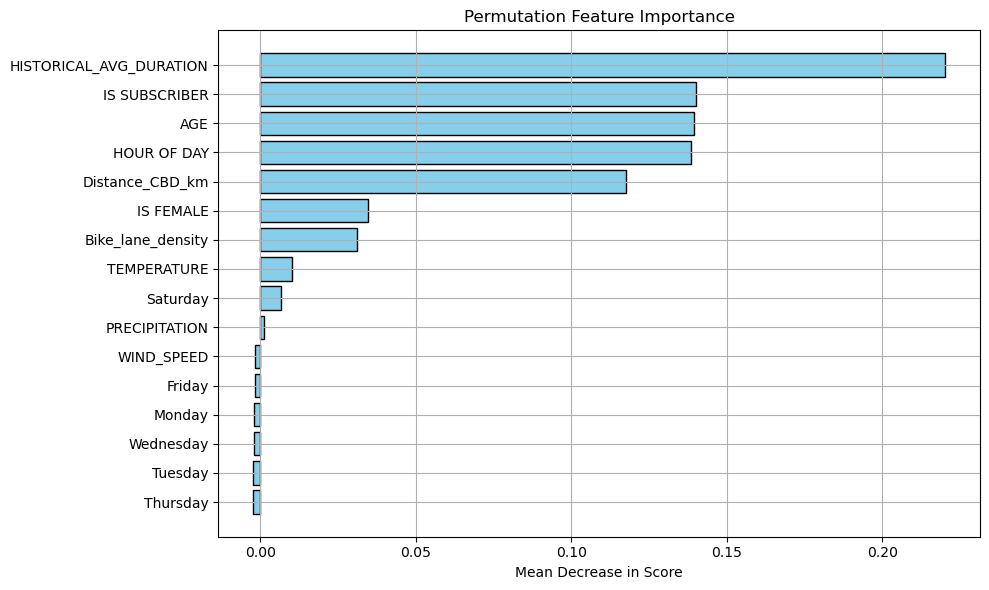

/opt/anaconda3/envs/DSML_env/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [123]:
from sklearn.inspection import permutation_importance

# Permutation Importance
result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


importances = result.importances_mean
indices = np.argsort(importances)[::-1] # sorts descending

# plot
plt.figure(figsize=(10, 6))
plt.barh(
    y=np.array(X.columns)[indices],
    width=importances[indices],
    align="center",
    color="skyblue",
    edgecolor="black"
)
plt.xlabel("Mean Decrease in Score")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis() 
plt.grid(True)
plt.tight_layout()
plt.show()

### -> The graph indicates that most weekday and weather features do not contribute meaningfully to the model’s predictions and likely cause unnecessary noise and complexity.

### To put that to the test we can re-evalute the model without those features:

## Random Forest without less important features

In [124]:
# feature selection
features = [
    "AGE", "IS FEMALE", "IS SUBSCRIBER", "HOUR OF DAY",
     "Saturday",
     "HISTORICAL_AVG_DURATION", "Distance_CBD_km", "Bike_lane_density"
]

# assigning data
X = bike_full[features]
y = bike_full["TRIP DURATION"]

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Basic Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100, # 100 trees
    random_state=42,
    n_jobs=-1
    )
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R2: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape * 100:.2f}%")
print(f"RMSE: {rmse:.2f}")

# tree data
print("\nTree data:")

total_n_leaves = 0
total_depth = 0

for estimator in rf_model.estimators_:
    total_n_leaves += estimator.get_n_leaves()
    total_depth += estimator.get_depth()
    

avg_n_leaves = total_n_leaves / len(rf_model.estimators_)
avg_depth = total_depth / len(rf_model.estimators_)

print(f"Average number of leafs per tree: {avg_n_leaves:.2f}")
print(f"Average depth of tree: {avg_depth:.2f}")


R2: 0.252
MAE: 4.88
MAPE: 62.05%
RMSE: 8.17

Tree data:
Average number of leafs per tree: 43596.80
Average depth of tree: 37.87


### -> all metrics improved

## Transforming the y values

The distribution of trip duration is very right-skewed and because a random forest uses the squared error to determine splits, outliers (extremely long trips) can have too much influence on how the model decides to split the data.

Therefore, it is possible that using a `log tranformation` on the target value helps with how these outliers impact the performance:

In [125]:
# feature selection
features = [
    "AGE", "IS FEMALE", "IS SUBSCRIBER", "HOUR OF DAY",
    "Saturday",
    "HISTORICAL_AVG_DURATION", "Distance_CBD_km", "Bike_lane_density"
    ]

# assigning data
X = bike_full[features]
y = np.log1p(bike_full["TRIP DURATION"]) # = log(1+x)

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)


# Basic Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100, # 100 trees
    random_state=42,
    n_jobs=-1
    )
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# scaling back for metrics
y_pred = np.expm1(y_pred) # = exp(x) - 1 | Inverse of log1p: returns original scale
y_test = np.expm1(y_test)

# metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R2: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape * 100:.2f}%")
print(f"RMSE: {rmse:.2f}")


# tree data
print("\nTree data:")

total_n_leaves = 0
total_depth = 0

for estimator in rf_model.estimators_:
    total_n_leaves += estimator.get_n_leaves()
    total_depth += estimator.get_depth()
    

avg_n_leaves = total_n_leaves / len(rf_model.estimators_)
avg_depth = total_depth / len(rf_model.estimators_)

print(f"Average number of leaves per tree: {avg_n_leaves:.2f}")
print(f"Average depth of tree: {avg_depth:.2f}")


R2: 0.259
MAE: 4.61
MAPE: 50.42%
RMSE: 8.00

Tree data:
Average number of leaves per tree: 43548.07
Average depth of tree: 38.41


### -> all metrics improved

## Hyperparamter tuning

As we saw in the previous models, the average tree depth and number of leaves were very high, which suggests that the model may be **overfitting** to the training data.

To address this, we can try to adjust the hyperparameters in order to build a more stable and reliable model using `Randomized Search Cross-Validation`.

Randomized Search Cross-Validation is a procedure in which a number of randomly selected combinations of hyperparameter values are evaluated using cross-validation.

In [126]:
from sklearn.model_selection import RandomizedSearchCV

# parameter distribution (96 possible combinations)
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [15, 20, 30, None],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5],
    "max_features": [None, 'sqrt']
}

# RandomizedSearchCV Setup
search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,              # 50 random combinations
    cv=3,                   # 3 fold cross validation
    scoring='r2',           # maximizes r2 score
    n_jobs=-1,
    random_state=42,
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)

python(64453) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(64454) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(64475) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(64476) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(64477) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(64803) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(64838) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(65171) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Best parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 30}


### Model with optimized hyperparameters:

In [132]:
# feature selection
features = [
    "AGE", "IS FEMALE", "IS SUBSCRIBER", "HOUR OF DAY",
     "Saturday",
     "HISTORICAL_AVG_DURATION", "Distance_CBD_km", "Bike_lane_density"
     ]

# assigning data
X = bike_full[features]
y = np.log1p(bike_full["TRIP DURATION"]) # = log(1+x)

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1000)


# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=300, 
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None,
    max_depth=30,
    random_state=42,
    n_jobs=-1
    )
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# scaling back for metrics
y_pred = np.expm1(y_pred) # = exp(x) - 1 | Inverse of log1p: returns original scale
y_test = np.expm1(y_test)

# metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R2: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape * 100:.2f}%")
print(f"RMSE: {rmse:.2f}")


# tree data
print("\nTree data:")

total_n_leaves = 0
total_depth = 0

for estimator in rf_model.estimators_:
    total_n_leaves += estimator.get_n_leaves()
    total_depth += estimator.get_depth()
    

avg_n_leaves = total_n_leaves / len(rf_model.estimators_)
avg_depth = total_depth / len(rf_model.estimators_)

print(f"Average number of leafs per tree: {avg_n_leaves:.2f}")
print(f"Average depth of tree: {avg_depth:.2f}")


R2: 0.253
MAE: 4.70
MAPE: 50.07%
RMSE: 8.24

Tree data:
Average number of leafs per tree: 12440.24
Average depth of tree: 30.00


### -> scores slightly worsened but the trees got significantly less complex, indicating a better trade-off between performance and generalizability

## Short vs. Long Trips

To determine if there is a difference in prediction when it's a short trip vs. when it's a long trip, we can seperate them and compare their scores:

In [128]:
# short trips (less than 40 minutes)
short = y_test < 40
r2_short = r2_score(y_test[short], y_pred[short])
mae_short = mean_absolute_error(y_test[short], y_pred[short])
mape_short = np.mean(np.abs((y_test[short] - y_pred[short]) / y_test[short])) * 100
rmse_short = np.sqrt(mean_squared_error(y_test[short], y_pred[short]))

# long trips (more than 40 minutes)
long = y_test >= 40
r2_long = r2_score(y_test[long], y_pred[long])
mae_long = mean_absolute_error(y_test[long], y_pred[long])
mape_long = np.mean(np.abs((y_test[long] - y_pred[long]) / y_test[long])) * 100
rmse_long = np.sqrt(mean_squared_error(y_test[long], y_pred[long]))

print("Trips < 40 min:")
print(f"R2: {r2_short:.3f}")
print(f"MAE: {mae_short:.2f}")
print(f"MAPE: {mape_short:.2f}%")
print(f"RMSE: {rmse_short:.2f}")

print("\nTrips >= 40 min:")
print(f"R2: {r2_long:.3f}")
print(f"MAE: {mae_long:.2f}")
print(f"MAPE: {mape_long:.2f}%")
print(f"RMSE: {rmse_long:.2f}")

Trips < 40 min:
R2: 0.248
MAE: 4.24
MAPE: 50.43%
RMSE: 6.41

Trips >= 40 min:
R2: -4.041
MAE: 37.06
MAPE: 64.58%
RMSE: 41.93


### -> Unfortunately, the metrics show that our model performs only moderately well on short trips, and performs very poorly on long trips.

## Final model

In [133]:
# only using short trips
bike_full[bike_full["TRIP DURATION"] < 40]

# feature selection
features = [
    "AGE", "IS FEMALE", "IS SUBSCRIBER", "HOUR OF DAY",
     "Saturday",
     "HISTORICAL_AVG_DURATION", "Distance_CBD_km", "Bike_lane_density"
     ]

# assigning data
X = bike_full[features]
y = np.log1p(bike_full["TRIP DURATION"]) # = log(1+x)

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1000)


# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=300, 
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None,
    max_depth=30,
    random_state=42,
    n_jobs=-1
    )
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# scaling back for metrics
y_pred = np.expm1(y_pred) # = exp(x) - 1 | Inverse of log1p: returns original scale
y_test = np.expm1(y_test)

# metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R2: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"MAPE: {mape * 100:.3f}%")
print(f"RMSE: {rmse:.3f}")


# tree data
print("\nTree data:")

total_n_leaves = 0
total_depth = 0

for estimator in rf_model.estimators_:
    total_n_leaves += estimator.get_n_leaves()
    total_depth += estimator.get_depth()
    

avg_n_leaves = total_n_leaves / len(rf_model.estimators_)
avg_depth = total_depth / len(rf_model.estimators_)

print(f"Average number of leafs per tree: {avg_n_leaves:.3f}")
print(f"Average depth of tree: {avg_depth:.3f}")


R2: 0.253
MAE: 4.703
MAPE: 50.074%
RMSE: 8.242

Tree data:
Average number of leafs per tree: 12440.237
Average depth of tree: 30.000


## Summary Model Performance: 
R2 score of 0.25 shows that our model can only explain 25% of variance of the trip duration, which is most likely not useful in a real-world enviroment. 

The MAE 4.7 minutes also indicate that the model’s predictions deviate very much the from actual value, especially considering we are only looking at short trips.

However, given the nature of a trip duration, it is likely that it is inherently difficult to predict the target value, at least with the features currently available. Factors such as user behavior, traffic or events may heavily influence the time that a user needs to reach his destination and are often too difficult, costly or random to capture.